# **Customer Churn Prediction – SyriaTel**

### **Background**

Customer churn refers to the loss of customers when they stop using a company's services. In the telecommunications industry, churn is a critical issue due to the highly competitive market and the relatively low switching costs for customers. When customers leave, companies not only lose recurring revenue but also incur additional costs associated with acquiring new customers to replace them.

Research and industry trends consistently show that retaining existing customers is significantly more cost-effective than acquiring new ones. Therefore, understanding and predicting customer churn is essential for maintaining long-term profitability and customer loyalty.

---

### **Business Problem**

SyriaTel is facing challenges with customer retention, as a portion of its customer base discontinues its services over time. Currently, the company may only react after customers have already churned, which limits its ability to recover lost revenue.

The key business problem is the lack of a proactive system to identify customers who are at risk of churning before they actually leave. Without this capability, SyriaTel cannot efficiently target retention efforts or allocate resources effectively.

This project aims to address this gap by developing a predictive model that can classify customers as likely to churn or not. By identifying high-risk customers in advance, the company can implement targeted interventions such as promotional offers, improved customer service, or personalized engagement strategies to reduce churn rates.

---

### **Stakeholders**

This project is relevant to several key stakeholders within SyriaTel:

- **Customer Retention Team**  
  This team is directly responsible for reducing churn. They can use the model's predictions to identify at-risk customers and take immediate action, such as offering incentives or resolving service issues.

- **Marketing Team**  
  The marketing team can use churn predictions to design targeted campaigns aimed at retaining high-risk customers. This allows for more efficient use of marketing resources and improves campaign effectiveness.

- **Business Strategy Team**  
  This team focuses on long-term planning and decision-making. Insights from the model, such as key drivers of churn, can inform strategic initiatives, product improvements, and policy changes to enhance customer satisfaction and retention.

---

### **Objective**

The primary objective of this project is to build a classification model that predicts whether a customer is likely to churn. The model will use historical customer data to identify patterns and factors associated with churn behavior.

In addition to prediction, the project also aims to uncover the most important features influencing churn. These insights will help SyriaTel better understand customer behavior and guide data-driven decision-making.

---

### **Why This Matters**

Reducing customer churn has significant business impact:

- **Increase Revenue**  
  Retaining customers ensures a steady stream of recurring revenue and reduces losses associated with customer departure.

- **Improve Customer Satisfaction**  
  By identifying and addressing issues early, the company can enhance the overall customer experience.

- **Reduce Marketing Costs**  
  Targeted retention strategies are more cost-effective than broad customer acquisition campaigns.

- **Enable Proactive Decision-Making**  
  Predictive insights allow the company to act before churn occurs, rather than reacting after the fact.

Ultimately, leveraging machine learning to predict churn enables SyriaTel to move from reactive to proactive customer management, improving both operational efficiency and business outcomes.

---

## **Data Understanding**

In [78]:
# Import necessary libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# For cleaner plots
sns.set(style="whitegrid")

In [79]:
# Load the dataset

churn_df = pd.read_csv("C:\\Users\\Admin\\Data_Science\\PHASE3\\customer-churn-prediction-phase3-project\\data\\SyriaTel_Customer_Churn.csv")
churn_df.head()

,state,account length,area code,phone number,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total day charge,...,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls,churn
0,KS,128,415,382-4657,no,yes,25,265.1,110,45.07,...,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,371-7191,no,yes,26,161.6,123,27.47,...,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,358-1921,no,no,0,243.4,114,41.38,...,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,375-9999,yes,no,0,299.4,71,50.90,...,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,330-6626,yes,no,0,166.7,113,28.34,...,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [80]:
# Checking the information of the dataset to understand the data types and missing values

churn_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   state                   3333 non-null   object 
 1   account length          3333 non-null   int64  
 2   area code               3333 non-null   int64  
 3   phone number            3333 non-null   object 
 4   international plan      3333 non-null   object 
 5   voice mail plan         3333 non-null   object 
 6   number vmail messages   3333 non-null   int64  
 7   total day minutes       3333 non-null   float64
 8   total day calls         3333 non-null   int64  
 9   total day charge        3333 non-null   float64
 10  total eve minutes       3333 non-null   float64
 11  total eve calls         3333 non-null   int64  
 12  total eve charge        3333 non-null   float64
 13  total night minutes     3333 non-null   float64
 14  total night calls       3333 non-null   

#### **Insights**
The dataset contains **3,333 observations** and **21 features**. It includes a mix of numerical `int64`, `float64` and categorical `object` variables.

The target variable, **`churn`**, is a boolean, confirming this is a **binary classification problem**.

There are **no missing values** in the dataset, which simplifies the data preparation process.

Some variables, such as `phone number`, are likely not useful for prediction since they act as unique identifiers.

---

## **Exploratory Data Analysis (EDA)**

### **Target Variable Distribution**

False    2850
True      483
Name: churn, dtype: int64


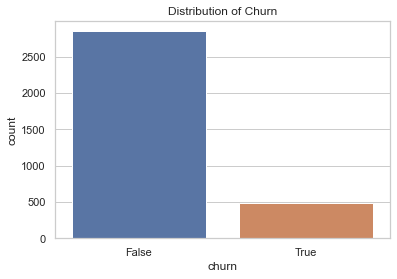

In [82]:
# Distribution of the target variable 'churn'
print(churn_df['churn'].value_counts())

sns.countplot(x='churn', data=churn_df)
plt.title('Distribution of Churn')
plt.show()

#### **Insights**
From the above output, there is class imbalance in the target variable **churn**.

**Class False** represents customers who did **not churn** and it is the **majority class** with 2850 customers.

**Class True** represents customers who **churn** and it is the **minority class** with 483 customers.

This class imbalance could affect the model, in that for most times it will predict the majority class.

---

### **Explore Numerical Features**

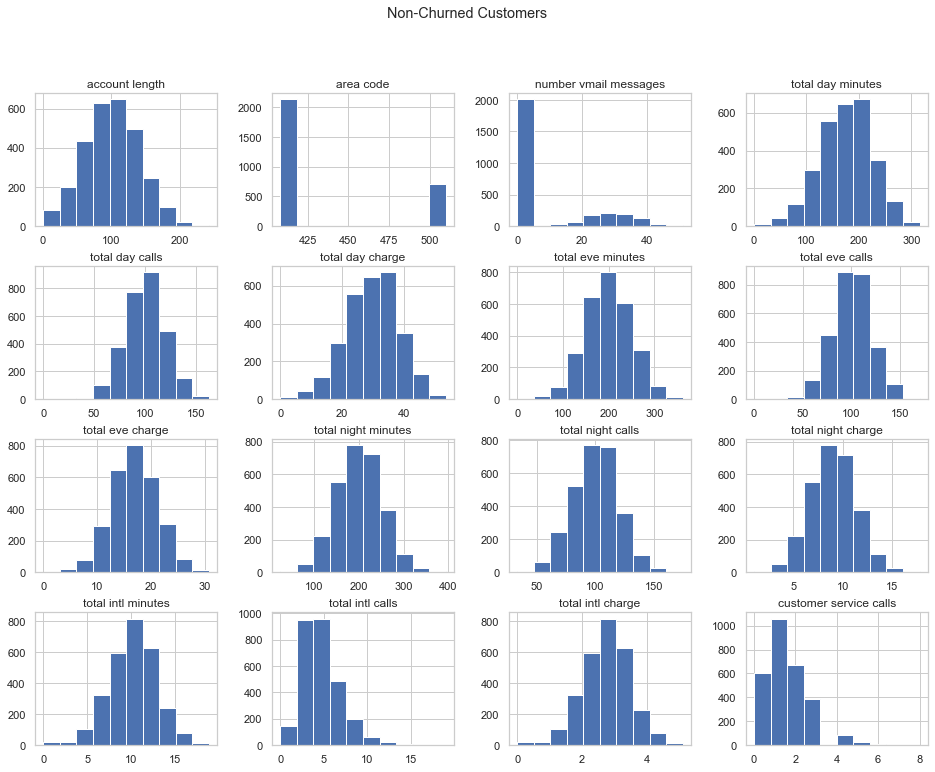

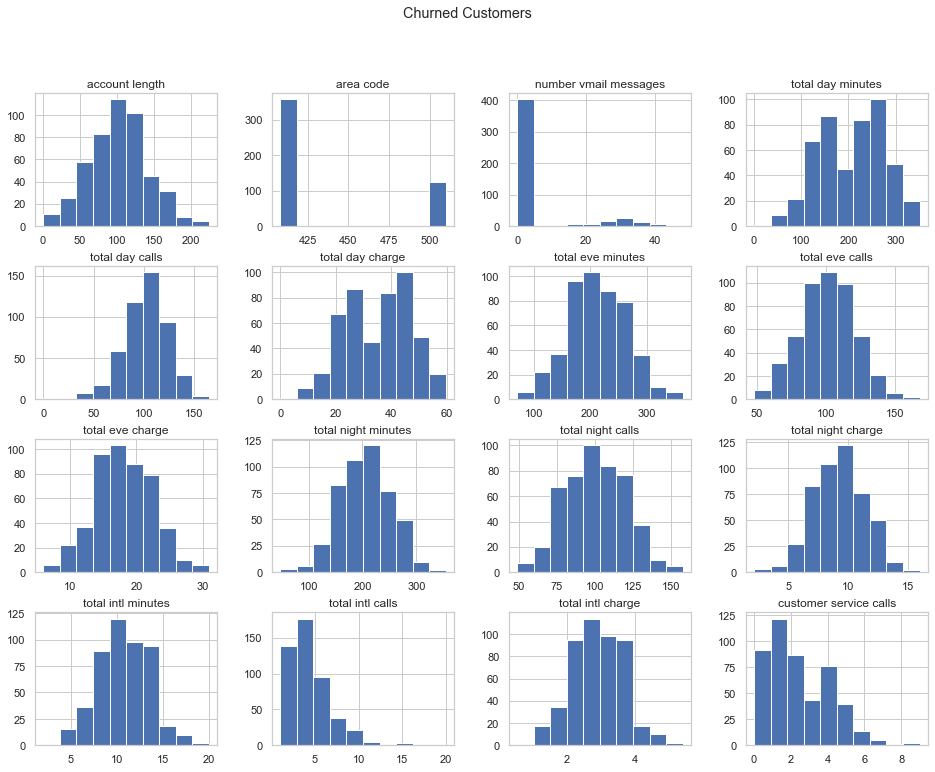

In [83]:
churn_df[churn_df['churn']==0].hist(figsize=(16,12))
plt.suptitle('Non-Churned Customers')
plt.show()

churn_df[churn_df['churn']==1].hist(figsize=(16,12))
plt.suptitle('Churned Customers')
plt.show()

#### **Insights**
1. **Customer Service Calls:**
    - Non-Churned: Concentrated at 0-2 calls(low dissatisfaction).
    - Churned: Spread out to 4-5+ calls, with higher frequency in higher bins.

Customers making frequent service calls are more likely to churn. Target retention for customers with 3+ calls.


2. **Total Day/ Evening/ Night Minutes:**
    - Non-churned: Normal distribution centered around 175-180 minutes.
    - Churned: Slightly shifted right (higher usage), with more customers in 200-250 minute range.

High usage might indicate business users or dissatisfaction leading to more calls.


3. **Voicemail Messages:**
    - Non-churned: More spread, some with 20-40 messages.
    - Churned: Heavily skewed to 0 messages, very few with voicemail plans.

Churners are less engaged with voicemail features, perhaps they do not value add-ons or are switching to competitors without them.


4. **Account Length:**
    - Non-churned: More uniform across 50-200 months.
    - Churned: Slightly more in shorter tenures (under 100 months).

Newer customers churn more, but not dramatically. Loyalty builds over time.


#### **Business Takeaway**
Offer perks for high-usage customers (e.g., discounted plans) and proactive support for frequent callers as a retention strategy.

---

### **Correlation Matrix**


The correlation matrix shows relationships between numerical variables.

- Values close to +1 or -1 indicate strong relationships
- Helps identify important features
- Helps detect multicollinearity

This information is useful when selecting features for modeling.

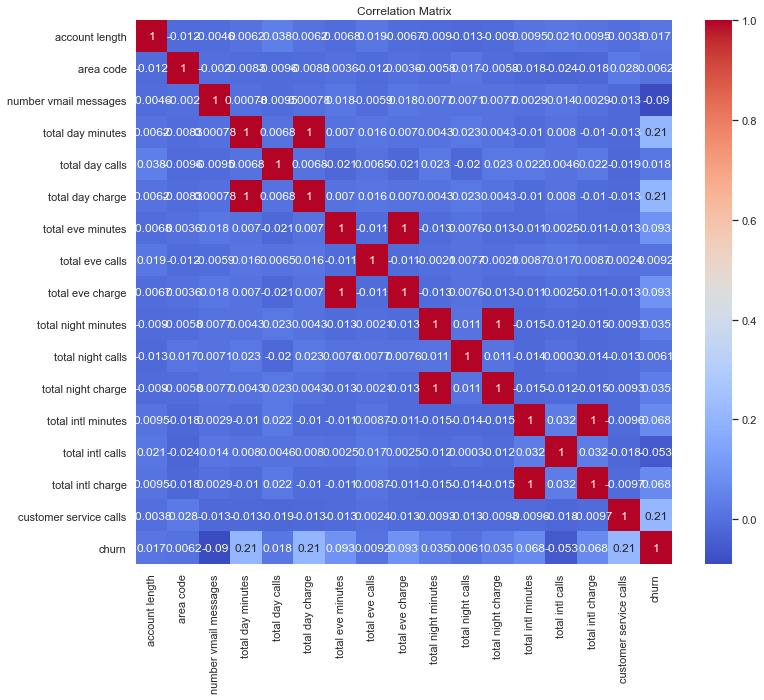

In [84]:
plt.figure(figsize=(12,10))
sns.heatmap(churn_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

#### **Insights**
From the correlation matrix above, there is multicollinearity between several features such as;
- total day minutes and total day charge: value= 1
- total eve minutes and total eve charge: value= 1
- total night minutes and total night charge: value= 1
- total intl minutes and total intl charge: value= 1


Multicollinearity between features could affect the model, we deal with it by dropping the features that are highly correlated.

---

### **Categorical Features vs Target Variable 'churn'**

### ***State vs Churn***

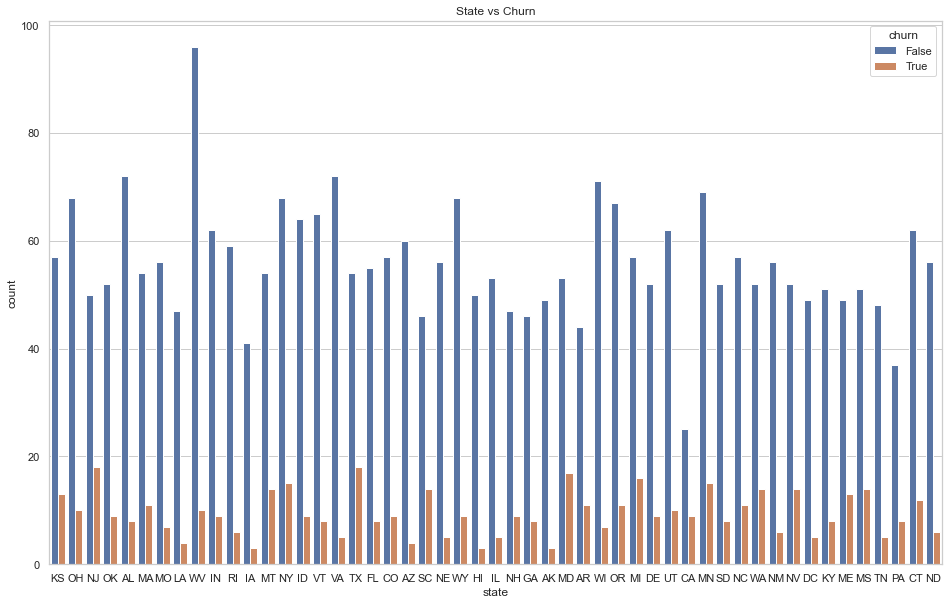

In [85]:
figure, ax = plt.subplots(figsize=(16, 10))
sns.countplot(x='state', hue='churn', data=churn_df)
plt.title("State vs Churn")
plt.show()

#### **Insights**
From the graph above, there is still an imbalance between the retained and churned customers for every state.

States such as NJ, TX, MD and MI have highest number of customers who churned.

---

In [86]:
# Calculate churn rate for each state

state_churn = churn_df.groupby('state')['churn'].agg(total_customers='count', churned='sum')
state_churn['churn_rate'] = state_churn['churned'] / state_churn['total_customers']
state_churn = state_churn.sort_values('churn_rate', ascending=False)

print(state_churn.head(10))

       total_customers  churned  churn_rate
state                                      
NJ                  68       18    0.264706
CA                  34        9    0.264706
TX                  72       18    0.250000
MD                  70       17    0.242857
SC                  60       14    0.233333
MI                  73       16    0.219178
MS                  65       14    0.215385
NV                  66       14    0.212121
WA                  66       14    0.212121
ME                  62       13    0.209677


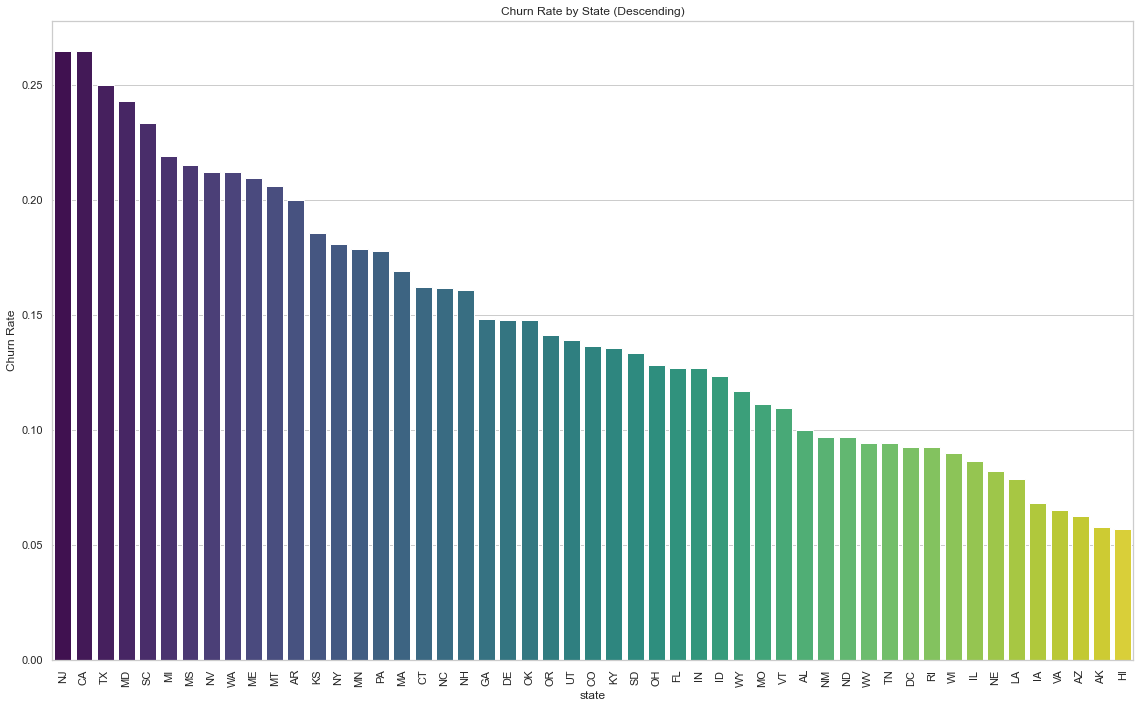

In [87]:
# Visualize churn rate by state

plt.figure(figsize=(16, 10))
sns.barplot(x=state_churn.index, y=state_churn['churn_rate'], palette='viridis')
plt.xticks(rotation=90)
plt.ylabel('Churn Rate')
plt.title('Churn Rate by State (Descending)')
plt.tight_layout()
plt.show()

#### **Insights**
States in the top such as NJ, CA, TX, MD, SC, MI, MS, NV, WA, and ME have the highest proportion of churned customers and are priority for retention action.


---

### ***International Plan vs Churn***

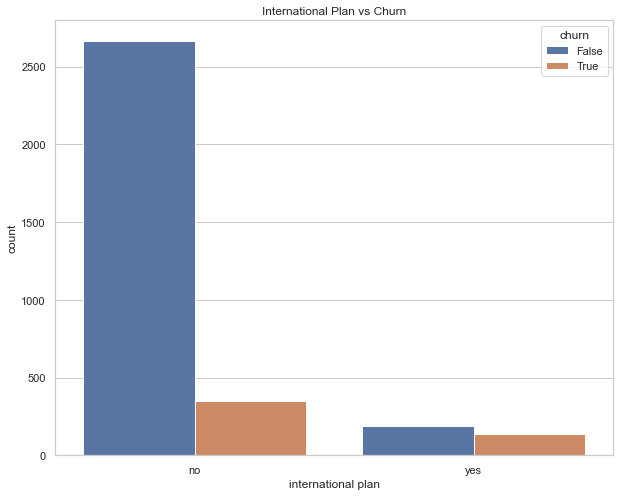

In [88]:
figure, ax = plt.subplots(figsize=(10, 8))
sns.countplot(x='international plan', hue='churn', data=churn_df)
plt.title("International Plan vs Churn")
plt.show()

#### **Insights**
**No international plan (majority):** approximately 2700 customers remained and approximately 300 customers churned. This means that the churn rate for customers with no international plan is approximately 10%.

**Yes international plan (small segment):** approximately 200 retained customers and 150 churned customers. With this the churn rate for customers with an international plan is approximately 43%.

Customers with an international plan are more likely to churn maybe due to higher costs, dissatisfaction or unmet usage needs.

International plan may signal a specific customer segment such as short-term, international travelers or business users.

---

### ***Voice Mail Plan vs Churn***

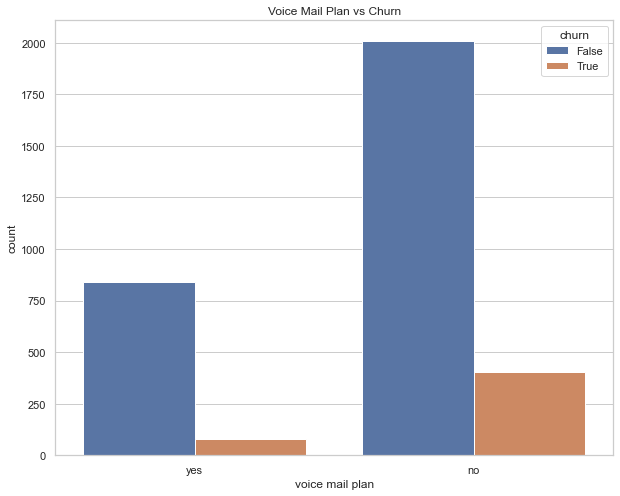

In [89]:
figure, ax = plt.subplots(figsize=(10, 8))
sns.countplot(x='voice mail plan', hue='churn', data=churn_df)
plt.title("Voice Mail Plan vs Churn")
plt.show()

#### **Insights**
Yes (Voicemail plan): approximately 850 retained and 75 churned customers. With this the approximate churn rate for customers with a voicemail plan is 8%.

No (Voicemail plan): approximate 2000 retained and 400 churned customers. The approximate churn rate is 17%.

Customers with a voicemail plan have a significantly lower churn rate.


#### **Business Takeaway**
Promote voicemail plan adoption to new/ at risk customers as a retention strategy. 

Offering free/ discounted voicemail plan could increase adoption.

---

## **Data Preparation**

From Data Understanding and EDA, the dataset has no missing values.

Tasks required in this section of data preparation are:
- Dropping irrelevant columns such as phone number
- Converting the target column to 0 and 1
- Handle multicollinearity among features
- Define the target and features
- Split the data into training and testing sets
- Scale the numerical features
- OneHotEncode the categorical features

### **Data Cleaning**

In [90]:
# Drop the 'phone number' column as it is not useful for analysis
churn_df.drop(columns=['phone number'], inplace=True)

# Convert 'churn' column from boolean to binary (1 for churned, 0 for not churned)
churn_df['churn'] = churn_df['churn'].astype(int)

churn_df.head()

,state,account length,area code,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total day charge,total eve minutes,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls,churn
0,KS,128,415,no,yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,0
1,OH,107,415,no,yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,0
2,NJ,137,415,no,no,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,0
3,OH,84,408,yes,no,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,0
4,OK,75,415,yes,no,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,0



The `phone number` column is removed because it is a unique identifier and does not provide meaningful information for predicting customer churn.
Including such features can introduce noise into the model without improving performance.

The `churn` variable is converted from boolean to numerical format (0 and 1). This is necessary because machine learning models require numerical input for both features and the target variable.

In [91]:
# Handle multicollinearity by dropping one of the highly correlated features

churn_df.drop(['total day charge', 'total eve charge', 'total night charge', 'total intl charge'], axis=1, inplace=True)
churn_df.head()  

,state,account length,area code,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total eve minutes,total eve calls,total night minutes,total night calls,total intl minutes,total intl calls,customer service calls,churn
0,KS,128,415,no,yes,25,265.1,110,197.4,99,244.7,91,10.0,3,1,0
1,OH,107,415,no,yes,26,161.6,123,195.5,103,254.4,103,13.7,3,1,0
2,NJ,137,415,no,no,0,243.4,114,121.2,110,162.6,104,12.2,5,0,0
3,OH,84,408,yes,no,0,299.4,71,61.9,88,196.9,89,6.6,7,2,0
4,OK,75,415,yes,no,0,166.7,113,148.3,122,186.9,121,10.1,3,3,0


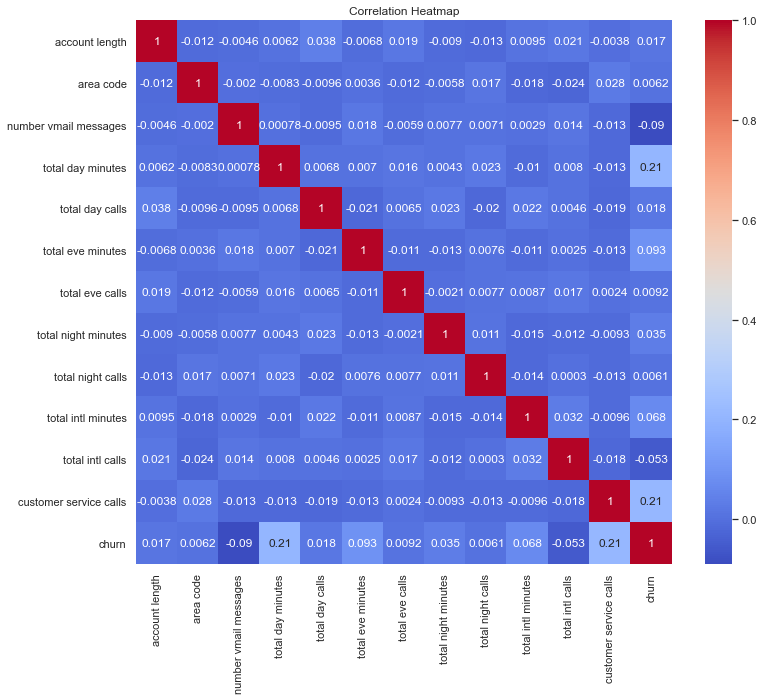

In [92]:
# Correlation matrix after dropping highly correlated features

figure, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(churn_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

### **Training and Testing Sets**

In [94]:
# Define the explanatory variables/ features

X = churn_df.drop('churn', axis=1)

# Define the target variable
y = churn_df['churn']

In [96]:
# Split the data into training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_train.head()

,state,account length,area code,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total eve minutes,total eve calls,total night minutes,total night calls,total intl minutes,total intl calls,customer service calls
606,RI,129,415,no,no,0,139.5,119,289.3,105,129.4,97,13.1,8,0
2468,WV,152,510,yes,yes,41,146.8,128,285.6,96,213.6,80,4.3,2,1
1844,SC,77,510,no,yes,28,135.9,117,244.5,102,207.5,74,11.5,3,4
3187,WV,58,408,no,yes,39,211.9,40,274.4,76,210.5,139,5.4,4,1
3083,MO,174,510,no,no,0,235.5,108,142.3,143,316.7,131,12.5,5,0


### **Scale Numerical Features**

Since we are going to use logistic regression, the best scaler to use is MinMaxscaler. This is because it transform values to fit within a range between 0 and 1.

In [99]:
from sklearn.preprocessing import MinMaxScaler

# Identify numeric columns for scaling
numeric_cols = X_train.select_dtypes(include=[np.number]).columns

X_train_numeric = X_train[numeric_cols].copy()
X_test_numeric = X_test[numeric_cols].copy()

# Initialize the scaler
scaler = MinMaxScaler()

# Fit the scaler on the training data and transform both training and testing data
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_numeric),
    index = X_train_numeric.index,
    columns = X_train_numeric.columns
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test_numeric),
    index = X_test_numeric.index,
    columns = X_test_numeric.columns
)

X_train_scaled.head()

,account length,area code,number vmail messages,total day minutes,total day calls,total eve minutes,total eve calls,total night minutes,total night calls,total intl minutes,total intl calls,customer service calls
606,0.528926,0.068627,0.000000,0.397662,0.721212,0.795436,0.617647,0.285637,0.450704,0.655,0.444444,0.000000
2468,0.623967,1.000000,0.803922,0.418472,0.775758,0.785263,0.564706,0.512103,0.330986,0.215,0.111111,0.111111
1844,0.314050,1.000000,0.549020,0.387400,0.709091,0.672257,0.600000,0.495697,0.288732,0.575,0.166667,0.444444
3187,0.235537,0.000000,0.764706,0.604048,0.242424,0.754468,0.447059,0.503765,0.746479,0.270,0.222222,0.111111
3083,0.714876,1.000000,0.000000,0.671323,0.654545,0.391257,0.841176,0.789403,0.690141,0.625,0.277778,0.000000


From the output above, we can see that MinMaxScaler has transformed the values to a range between 0 and 1. No value is below 0 or above 1.

Also notice that we are not fitting in the test data and we are only transforming to avoid leakage.

### **OneHotEncode Categorical Features**


In [102]:
from sklearn.preprocessing import OneHotEncoder

# Identify categorical columns for encoding
categorical_cols = X_train.select_dtypes(include=['object']).columns

X_train_categorical = X_train[categorical_cols].copy()

# Instantiate OneHotEncoder
ohe = OneHotEncoder(sparse= False)

# Fit and transform the training set
X_train_ohe = pd.DataFrame(
    ohe.fit_transform(X_train_categorical),
    index = X_train_categorical.index,
    columns = ohe.get_feature_names(categorical_cols)
)

X_train_ohe.head()

,state_AK,state_AL,state_AR,state_AZ,state_CA,state_CO,state_CT,state_DC,state_DE,state_FL,...,state_VA,state_VT,state_WA,state_WI,state_WV,state_WY,international plan_no,international plan_yes,voice mail plan_no,voice mail plan_yes
606,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
2468,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0
1844,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
3187,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0
3083,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


In [103]:
# Transform the testing set using the same encoder fitted on the training set
X_test_categorical = X_test[categorical_cols].copy()

X_test_ohe = pd.DataFrame(
    ohe.transform(X_test_categorical),
    index = X_test_categorical.index,
    columns = ohe.get_feature_names(categorical_cols)
)

X_test_ohe.head()

,state_AK,state_AL,state_AR,state_AZ,state_CA,state_CO,state_CT,state_DC,state_DE,state_FL,...,state_VA,state_VT,state_WA,state_WI,state_WV,state_WY,international plan_no,international plan_yes,voice mail plan_no,voice mail plan_yes
68,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1653,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
1716,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
3251,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
2406,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


We start by creating an instance of the class OneHotEncoder so that to encode the categorical variables into binary which the model easily understands.

We are only transforming the test data so that to prevent data leakage to the model.

### **Preprocessed Training and Test Sets**

In [104]:
# Preprocessed training set

X_train_preprocessed = pd.concat([X_train_scaled, X_train_ohe], axis=1)
X_train_preprocessed.head()

,account length,area code,number vmail messages,total day minutes,total day calls,total eve minutes,total eve calls,total night minutes,total night calls,total intl minutes,...,state_VA,state_VT,state_WA,state_WI,state_WV,state_WY,international plan_no,international plan_yes,voice mail plan_no,voice mail plan_yes
606,0.528926,0.068627,0.000000,0.397662,0.721212,0.795436,0.617647,0.285637,0.450704,0.655,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
2468,0.623967,1.000000,0.803922,0.418472,0.775758,0.785263,0.564706,0.512103,0.330986,0.215,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0
1844,0.314050,1.000000,0.549020,0.387400,0.709091,0.672257,0.600000,0.495697,0.288732,0.575,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
3187,0.235537,0.000000,0.764706,0.604048,0.242424,0.754468,0.447059,0.503765,0.746479,0.270,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0
3083,0.714876,1.000000,0.000000,0.671323,0.654545,0.391257,0.841176,0.789403,0.690141,0.625,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


In [105]:
# Preprocessed testing set

X_test_preprocessed = pd.concat([X_test_scaled, X_test_ohe], axis=1)
X_test_preprocessed.head()

,account length,area code,number vmail messages,total day minutes,total day calls,total eve minutes,total eve calls,total night minutes,total night calls,total intl minutes,...,state_VA,state_VT,state_WA,state_WI,state_WV,state_WY,international plan_no,international plan_yes,voice mail plan_no,voice mail plan_yes
68,0.516529,0.0,0.000000,0.603193,0.424242,0.596371,0.470588,0.350457,0.190141,0.390,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1653,0.380165,1.0,0.000000,0.374572,0.472727,0.604069,0.623529,0.356374,0.492958,0.555,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
1716,0.144628,1.0,0.490196,0.435576,0.666667,0.667583,0.394118,0.334051,0.288732,0.455,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
3251,0.359504,0.0,0.000000,0.782782,0.636364,0.442947,0.711765,0.460463,0.633803,0.460,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
2406,0.330579,1.0,0.000000,0.415051,0.357576,0.791586,0.770588,0.426304,0.619718,0.460,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


## **Modeling**

In this section, we build and evaluate multiple classification models to predict customer churn.

We follow an iterative approach:

1. Baseline Logistic Regression model  
2. Tuned Logistic Regression model  
3. Decision Tree model  

This allows us to compare performance and select the most suitable model based on business needs, particularly focusing on recall. We focus on **recall** because failing to identify a customer who will churn results in lost revenue.


### **Baseline Logistic Regression Model**

In [106]:
from sklearn.linear_model import LogisticRegression

# Baseline model
baseline_model = LogisticRegression(max_iter=1000)

baseline_model.fit(X_train_preprocessed, y_train)

LogisticRegression(max_iter=1000)

#### **Evaluate Baseline Model**

We evaluate the model using:

- **Precision**: How many predicted churners are actually churners  
- **Recall**: How many actual churners are correctly identified  
- **F1-score**: Balance between precision and recall  

We prioritize **recall** because failing to identify a customer who will churn results in lost revenue.

The confusion matrix provides a breakdown of correct and incorrect predictions.

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred_baseline = baseline_model.predict(X_test_preprocessed)

print(classification_report(y_test, y_pred_baseline))
print(confusion_matrix(y_test, y_pred_baseline))

# AUC-ROC curve for the baseline model
from sklearn.metrics import roc_curve, auc
y_pred_proba_baseline = baseline_model.predict_proba(X_test_preprocessed)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_baseline)

auc_baseline = roc_auc_score(y_test, y_pred_proba_baseline)


              precision    recall  f1-score   support

           0       0.88      0.98      0.93       855
           1       0.66      0.23      0.34       145

    accuracy                           0.87      1000
   macro avg       0.77      0.60      0.63      1000
weighted avg       0.85      0.87      0.84      1000

[[838  17]
 [112  33]]


##### **Key Findings**

The baseline Logistic Regression model achieved an overall **accuracy of 87%**, indicating that it correctly classified most customers. However, accuracy alone can be misleading due to class imbalance.

Focusing on the churn class (1):

- **Precision = 0.66**  
  This means that when the model predicts a customer will churn, it is correct 66% of the time.

- **Recall = 0.23**  
  This indicates that the model only identifies **23% of actual churners**, missing a large majority of customers who eventually leave.

- **F1-score = 0.34**  
  This reflects poor balance between precision and recall for the churn class.

From the confusion matrix:

- **33 customers were correctly identified as churners (True Positives)**  
- **112 churners were missed (False Negatives)**  
- **17 non-churners were incorrectly predicted as churners (False Positives)**  
- **838 non-churners were correctly identified (True Negatives)**  


##### **Key Insight**

The model performs well in identifying non-churners but performs poorly in detecting churners.


##### **Business Implication**

This is a significant limitation because **missing churn customers (False Negatives)** means the company loses the opportunity to retain them. In this case, the model fails to identify the majority of at-risk customers, which reduces its usefulness for proactive retention strategies.


##### **Conclusion**

Although the baseline model provides a good starting point, its low recall for churn makes it insufficient for the business objective. Therefore, improvements are necessary to better capture customers at risk of churning.

---


### **Tuned Logistic Regression Model**
The baseline logistic regression model has a **Recall 0f 0.23** for class 1, this is poor as the model is missing a lot of customers who churn hence leading to loss in revenue.

To try solve this, we are going to handle class imbalance using SMOTE.

In [108]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train_preprocessed, y_train)

In [128]:
# Fit the Tuned Logistic Regression model

tuned_model = LogisticRegression(C=0.01, max_iter=1000, solver='liblinear', random_state=42)
tuned_model.fit(X_train_smote, y_train_smote)

LogisticRegression(C=0.01, max_iter=1000, random_state=42, solver='liblinear')

#### **Evaluate the Tuned Logistic Regression**

In [126]:
y_pred_tuned = tuned_model.predict(X_test_preprocessed)

print(classification_report(y_test, y_pred_tuned))
print(confusion_matrix(y_test, y_pred_tuned))

              precision    recall  f1-score   support

           0       0.94      0.76      0.84       855
           1       0.33      0.70      0.44       145

    accuracy                           0.75      1000
   macro avg       0.63      0.73      0.64      1000
weighted avg       0.85      0.75      0.78      1000

[[646 209]
 [ 44 101]]




##### **Key Findings**

After applying SMOTE to address class imbalance and tuning the Logistic Regression model, there is a significant shift in model performance.

Focusing on the churn class (1):

- **Precision = 0.33**  
  When the model predicts a customer will churn, it is correct 33% of the time.

- **Recall = 0.70**  
  The model now correctly identifies **70% of actual churners**, a substantial improvement from the baseline model.

- **F1-score = 0.44**  
  This reflects an improved balance between precision and recall compared to the baseline.

From the confusion matrix:

- **101 customers were correctly identified as churners (True Positives)**  
- **44 churners were missed (False Negatives)**  
- **209 non-churners were incorrectly predicted as churners (False Positives)**  
- **646 non-churners were correctly identified (True Negatives)**  


##### **Key Insight**

The model shows a **major improvement in recall**, increasing from 23% in the baseline model to 70%. This means far fewer churners are being missed.

However, this improvement comes at the cost of lower precision and overall accuracy, as more non-churners are incorrectly classified as churners.


##### **Business Implication**

This trade-off is acceptable in this context because:

- Identifying churn customers is more important than avoiding false alarms  
- False positives (incorrectly flagging non-churners) may lead to minor additional costs (e.g., offering promotions)  
- False negatives (missing churners) result in lost revenue, which is more costly  


##### **Conclusion**

The tuned model is significantly more effective for the business objective, as it successfully identifies the majority of customers at risk of churning. Despite the increase in false positives, the improvement in recall makes this model more suitable for proactive customer retention strategies.

---

## **Model Comparison**


We evaluated two main models:

#### 1. Baseline Logistic Regression
- Accuracy: 87%
- Recall (Churn): 23%

#### 2. Tuned Logistic Regression (with SMOTE)
- Accuracy: 75%
- Recall (Churn): 70%

#### Key Differences

- The baseline model achieved higher overall accuracy but performed poorly in identifying churners.
- The tuned model significantly improved recall, correctly identifying the majority of customers who churn.
- This improvement came at the cost of lower precision and accuracy, due to an increase in false positives.

#### Interpretation

The baseline model is biased toward predicting non-churners, which results in many missed churn cases. In contrast, the tuned model prioritizes detecting churners, making it more aligned with the business objective.

---


### **Final Model Selection**

The **tuned Logistic Regression model with SMOTE** is selected as the final model.

#### Justification

- It achieves a **recall of 70%**, meaning it successfully identifies the majority of customers at risk of churning.
- This is a substantial improvement over the baseline model, which only identified 23% of churners.
- The model aligns with the business goal of minimizing customer loss.

#### Trade-Offs

- The model produces more false positives, meaning some non-churn customers are incorrectly flagged.
- However, this is acceptable because the cost of offering retention incentives is lower than the cost of losing customers.

Overall, the tuned model provides the best balance between predictive performance and business value.

---

## **Business Recommendations**